In [1]:
pip install numpy pandas matplotlib seaborn joblib scikit-learn ipykernel

In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

from sklearn.neighbors       import KNeighborsClassifier
from sklearn.linear_model    import Ridge
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    mean_absolute_error, r2_score
)

# CHANGE THIS to your local data path
BASE_PATH = r"C:\Users\Fathi\pw"
FILE_NAME     = "09_filtered_all_data.pkl"
SAVE_DIR      = os.path.join(BASE_PATH, "models_fathia")
FULL_PATH     = os.path.join(BASE_PATH, FILE_NAME)

WINDOW_SIZE   = 200
STEP_SIZE     = 100
K_VALUES      = [3, 5, 7]

GONIO_TARGETS = ['G_DA_X', 'G_DA_Y', 'G_DK_X', 'G_DK_Y']
GONIO_NAMES   = {
    'G_DA_X': 'Dominant Ankle X',  'G_DA_Y': 'Dominant Ankle Y',
    'G_DK_X': 'Dominant Knee X',   'G_DK_Y': 'Dominant Knee Y'
}

## 1. Load Data

In [4]:
df = pd.read_pickle(FULL_PATH)

# ── Subsample to reduce memory ──────────────────────────────
df = df.sample(frac=0.2, random_state=42).reset_index(drop=True)  # use 20% of data
# ────────────────────────────────────────────────────────────

df[df.select_dtypes('float64').columns] = df.select_dtypes('float64').astype('float32')
df['Activity'] = df['Activity'].str.rstrip('_')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df['Activity'].value_counts().to_string())

Shape: 297,670 rows x 162 columns
Activity
run      73455
walk     72558
step     55423
sts      53219
squat    43015


## 2. EMG Spatial Pooling


In [5]:
ta_cols = [c for c in df.columns if 'EMG_TA' in c]
gm_cols = [c for c in df.columns if 'EMG_GM' in c]

for i in range(0, 64, 16):
    df[f'EMG_TA_Pool_{i//16}'] = df[ta_cols[i:i+16]].mean(axis=1)
    df[f'EMG_GM_Pool_{i//16}'] = df[gm_cols[i:i+16]].mean(axis=1)

df.drop(columns=ta_cols + gm_cols, inplace=True)

print(f"EMG reduced: 128 channels -> 8 pooled channels")
print(f"DataFrame shape after pooling: {df.shape}")

EMG reduced: 128 channels -> 8 pooled channels
DataFrame shape after pooling: (297670, 42)


## 3. Window Segmentation and Feature Extraction

Slides a window across the signal and extracts time-domain features per window:
- **EMG:** RMS, Mean Absolute Value (MAV), Waveform Length (WL), Zero Crossings (ZC)
- **IMU:** Mean, Standard Deviation, RMS, Energy
- **Label:** majority vote across the window
- **Regression target:** mean joint angle per window (4 goniometer channels)

In [7]:
emg_data   = df[[c for c in df.columns if 'Pool' in c]].to_numpy(dtype=np.float32)
imu_data   = df[[c for c in df.columns if c.endswith(('-f','-c','-q','-h'))]].to_numpy(dtype=np.float32)
gonio_data = df[GONIO_TARGETS].to_numpy(dtype=np.float32)
labels     = df['Activity'].values

X_list, y_clf_list, y_reg_list = [], [], []

for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
    end            = start + WINDOW_SIZE
    unique, counts = np.unique(labels[start:end], return_counts=True)
    label          = unique[np.argmax(counts)]

    if pd.isna(label):
        continue

    w_emg, w_imu = emg_data[start:end], imu_data[start:end]

    feats = np.concatenate([
        np.sqrt(np.mean(w_emg**2, axis=0)),
        np.mean(np.abs(w_emg), axis=0),
        np.sum(np.abs(np.diff(w_emg, axis=0)), axis=0),
        np.sum((w_emg[:-1] * w_emg[1:]) < 0, axis=0),
        np.mean(w_imu, axis=0),
        np.std(w_imu, axis=0),
        np.sqrt(np.mean(w_imu**2, axis=0)),
        np.sum(w_imu**2, axis=0)
    ])

    X_list.append(feats)
    y_clf_list.append(label)
    y_reg_list.append(np.mean(gonio_data[start:end], axis=0))

X     = np.array(X_list,     dtype=np.float32)
y_clf = np.array(y_clf_list)
y_reg = np.array(y_reg_list, dtype=np.float32)

print(f"Feature matrix:   {X.shape[0]:,} windows x {X.shape[1]} features")
print(f"Classifier labels: {y_clf.shape}")
print(f"Regressor targets: {y_reg.shape}  (4 joint angles per window)")

Feature matrix:   2,975 windows x 128 features
Classifier labels: (2975,)
Regressor targets: (2975, 4)  (4 joint angles per window)


## 4. Train/Test Split and Normalization


In [8]:
# ── FIX: drop classes that have fewer than 2 windows ────────
# stratify=y_clf requires >= 2 samples per class.
# With frac=0.2 + random shuffle, rare windows can drop to 1.
counts        = Counter(y_clf)
valid_classes = {cls for cls, n in counts.items() if n >= 2}
removed       = {cls: n for cls, n in counts.items() if n < 2}
if removed:
    print(f"WARNING: Removed classes with < 2 windows (can't stratify): {removed}")
    print("  Tip: increase frac= in sample() (e.g. frac=0.5) to keep all classes.")

mask       = np.array([lbl in valid_classes for lbl in y_clf])
X_filt     = X[mask]
y_clf_filt = y_clf[mask]
y_reg_filt = y_reg[mask]
# ─────────────────────────────────────────────────────────────

# Classifier split — stratify keeps class proportions equal in both sets
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X_filt, y_clf_filt, test_size=0.2, random_state=42, stratify=y_clf_filt
)

# Regressor split — same windows, different labels
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_filt, y_reg_filt, test_size=0.2, random_state=42
)

# Normalize — scaler fitted only on training data to prevent data leakage
scaler_clf     = StandardScaler()
X_train_sc     = scaler_clf.fit_transform(X_train)
X_test_sc      = scaler_clf.transform(X_test)

scaler_reg     = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

  Tip: increase frac= in sample() (e.g. frac=0.5) to keep all classes.
Train: 2,379  |  Test: 595


## 5. KNN Classifier

Tests K = 3, 5, 7 and keeps the best performing value.

In [9]:
best_knn, best_k, best_acc, y_pred_clf = None, None, 0, None

for k in K_VALUES:
    knn    = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_sc, y_clf_train)
    y_pred = knn.predict(X_test_sc)
    acc    = (y_pred == y_clf_test).mean() * 100
    print(f"K={k}  Accuracy={acc:.2f}%")
    if acc > best_acc:
        best_knn, best_k, best_acc, y_pred_clf = knn, k, acc, y_pred

print(f"\nBest: K={best_k}  Accuracy={best_acc:.2f}%")
# zero_division=0 suppresses warnings for classes with no predicted samples
print(classification_report(y_clf_test, y_pred_clf, zero_division=0))

K=3  Accuracy=62.52%
K=5  Accuracy=65.71%
K=7  Accuracy=66.89%

Best: K=7  Accuracy=66.89%
              precision    recall  f1-score   support

         run       0.71      0.76      0.73       313
        step       0.00      0.00      0.00        16
         sts       0.00      0.00      0.00        11
        walk       0.63      0.63      0.63       255

    accuracy                           0.67       595
   macro avg       0.33      0.35      0.34       595
weighted avg       0.64      0.67      0.65       595



## 6. Confusion Matrix — KNN Classifier

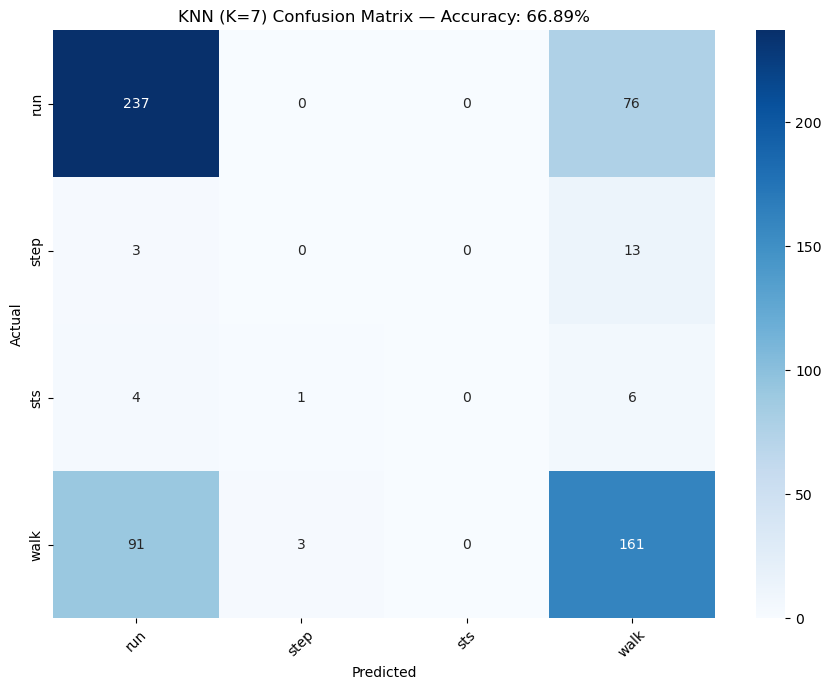

In [10]:
class_labels = sorted(set(y_clf_test))

plt.figure(figsize=(9, 7))
sns.heatmap(
    confusion_matrix(y_clf_test, y_pred_clf, labels=class_labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels
)
plt.title(f'KNN (K={best_k}) Confusion Matrix — Accuracy: {best_acc:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'knn_confusion_matrix.png'), dpi=150)
plt.show()

## 7. Ridge Regressor — Joint Angle Prediction


In [16]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_reg_train_sc, y_reg_train)
y_pred_reg = ridge.predict(X_reg_test_sc)

print(f"{'Joint Angle':<25} {'MAE (deg)':>10} {'R2':>8}")
print("-" * 45)
for i, col in enumerate(GONIO_TARGETS):
    mae = mean_absolute_error(y_reg_test[:, i], y_pred_reg[:, i])
    r2  = r2_score(y_reg_test[:, i], y_pred_reg[:, i])
    print(f"{GONIO_NAMES[col]:<25} {mae:>10.2f} {r2:>8.4f}")

Joint Angle                MAE (deg)       R2
---------------------------------------------
Dominant Ankle X                0.06   0.7757
Dominant Ankle Y                0.13   0.8313
Dominant Knee X                 0.70   0.8283
Dominant Knee Y                 0.13   0.7339


## 8. Regression Plots — Predicted vs Actual Joint Angles

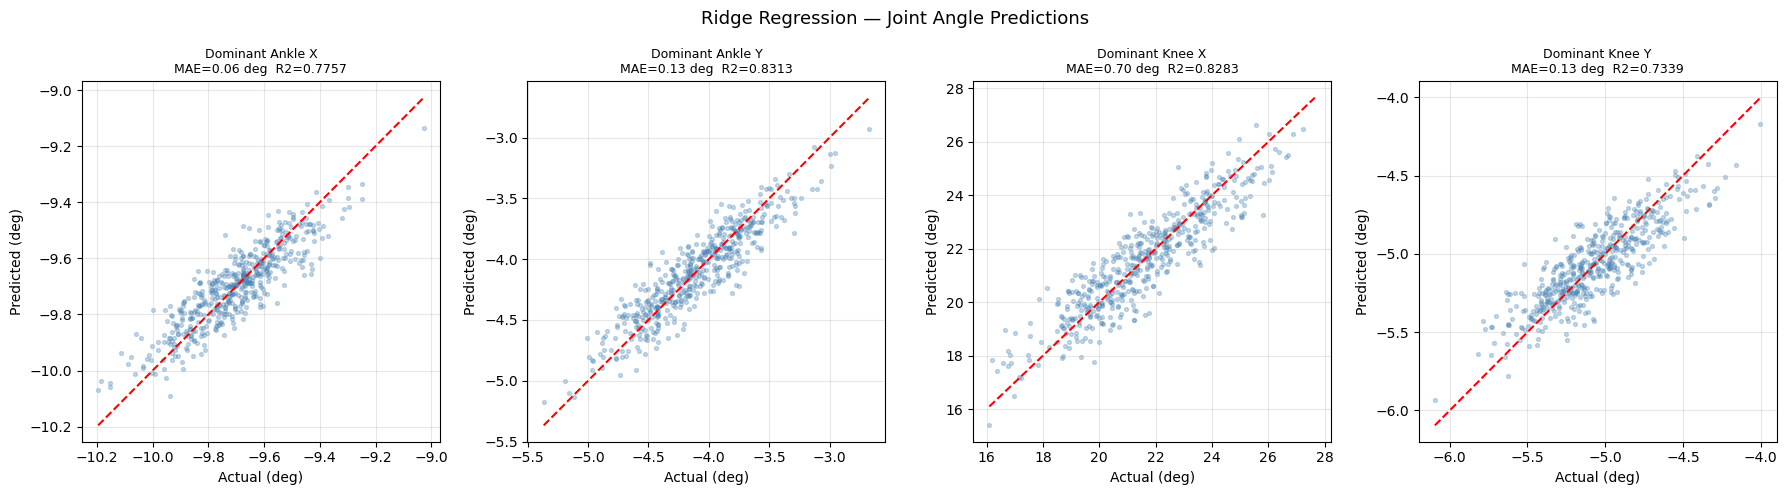

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Ridge Regression — Joint Angle Predictions', fontsize=13)
n_plot = 500

for i, col in enumerate(GONIO_TARGETS):
    y_true = y_reg_test[:, i]
    y_pred = y_pred_reg[:, i]
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    ax     = axes[i]

    ax.scatter(y_true[:n_plot], y_pred[:n_plot], alpha=0.3, s=8, color='steelblue')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=1.5)
    ax.set_title(f"{GONIO_NAMES[col]}\nMAE={mae:.2f} deg  R2={r2:.4f}", fontsize=9)
    ax.set_xlabel('Actual (deg)')
    ax.set_ylabel('Predicted (deg)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'ridge_regression_results.png'), dpi=150)
plt.show()

## 9. Summary

In [13]:
def infer_time_ms(model, sample, n=200, warmup=20):
    times = []
    for _ in range(n):
        t0 = time.time()
        model.predict(sample)
        times.append((time.time() - t0) * 1000)
    return np.mean(times[warmup:])

clf_ms = infer_time_ms(best_knn, X_test_sc[0:1])
reg_ms = infer_time_ms(ridge,    X_reg_test_sc[0:1])

print(f"KNN (K={best_k})")
print(f"  Accuracy       {best_acc:.2f}%")
print(f"  Inference      {clf_ms:.4f} ms per sample")
print(f"  Features       {X_train.shape[1]}")
print(f"  Train samples  {len(X_train):,}")

print(f"\nRidge Regression (alpha=1.0)")
print(f"  Inference      {reg_ms:.4f} ms per sample")
print(f"  {'Joint Angle':<25} {'MAE':>8} {'R2':>8}")
print(f"  {'-'*43}")
for i, col in enumerate(GONIO_TARGETS):
    mae = mean_absolute_error(y_reg_test[:, i], y_pred_reg[:, i])
    r2  = r2_score(y_reg_test[:, i], y_pred_reg[:, i])
    print(f"  {GONIO_NAMES[col]:<25} {mae:>7.2f} deg {r2:>8.4f}")

KNN (K=7)
  Accuracy       66.89%
  Inference      2.0046 ms per sample
  Features       128
  Train samples  2,379

Ridge Regression (alpha=1.0)
  Inference      0.1054 ms per sample
  Joint Angle                    MAE       R2
  -------------------------------------------
  Dominant Ankle X             0.06 deg   0.7757
  Dominant Ankle Y             0.13 deg   0.8313
  Dominant Knee X              0.70 deg   0.8283
  Dominant Knee Y              0.13 deg   0.7339


## 10. Save Models

In [17]:
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_knn,   os.path.join(SAVE_DIR, f'knn_k{best_k}.pkl'))
joblib.dump(ridge,      os.path.join(SAVE_DIR, 'ridge_regressor.pkl'))
joblib.dump(scaler_clf, os.path.join(SAVE_DIR, 'scaler_classifier.pkl'))
joblib.dump(scaler_reg, os.path.join(SAVE_DIR, 'scaler_regressor.pkl'))

print(f"Saved to: {SAVE_DIR}")
print(f"  knn_k{best_k}.pkl")
print(f"  ridge_regressor.pkl")
print(f"  scaler_classifier.pkl")
print(f"  scaler_regressor.pkl")

Saved to: C:\Users\Fathi\pw\models_fathia
  knn_k7.pkl
  ridge_regressor.pkl
  scaler_classifier.pkl
  scaler_regressor.pkl
